# **Summary Optimization and Computational Complexity Analysis**

Implement greedy algorithms using hybrid model predictions for optimal review summarization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
import pickle
import os
import time
import psutil
from collections import defaultdict, Counter
from itertools import combinations
import networkx as nx
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)


## **1. Load Clustering Results**

In [3]:
import gdown

# Google Drive file IDs (extract from your shareable links)
# Example: https://drive.google.com/file/d/FILE_ID/view?usp=sharing
DRIVE_FILES = {
    'graph_clustering_results.pkl': '1RWoib0Rjcx5xXpqTHkrXHIg5bPakbUH6',
    'cluster_assignments.pkl': '1IygvQ2F0tnK_GzLhBjHiSgysqBnz_Ov_',
    'all_predictions_for_optimization.pkl': '1azJ_oO-664ObU89M3bUkfX7Wo8PZUhQ8'
}

def download_files_from_drive(pathname, filename):
    """Download models from Google Drive using direct links"""
    # Create models directory
    os.makedirs('../{pathname}', exist_ok=True)

    
    print("Downloading models from Google Drive...")
    output_path = f'../{pathname}/{filename}'
    
    if not os.path.exists(output_path):
        print(f"   Downloading {filename}...")
        url = f'https://drive.google.com/uc?id={file_id}'
        gdown.download(url, output_path, quiet=False)
    else:
        print(f"   ✅ {filename} already exists")

### 1.1 Load clustering results

In [5]:
download_files_from_drive("results/graph_clustering", "graph_clustering_results.pkl")
download_files_from_drive("results/graph_clustering", "cluster_assignments.pkl")

try:
    with open('../results/graph_clustering/graph_clustering_results.pkl', 'rb') as f:
        clustering_results = pickle.load(f)
    
    with open('../results/graph_clustering/cluster_assignments.pkl', 'rb') as f:
        cluster_assignments = pickle.load(f)
    
    print("✅ Clustering results loaded")
    
except FileNotFoundError:
    print("❌ Clustering results not found. Please run Notebook 06 first.")
    exit(1)

   ✅ graph_clustering_results.pkl already exists
   ✅ cluster_assignments.pkl already exists
✅ Clustering results loaded


### 1.2 Load model predictions and embeddings

In [12]:
download_files_from_drive("results/hybrid_classification", "all_predictions_for_optimization.pkl")

try:
    with open('../results/hybrid_classification/all_predictions_for_optimization.pkl', 'rb') as f:
        predictions_package = pickle.load(f)
    
    # Load embeddings
    embeddings_test = np.load('../embeddings/hotel_bert_test_embeddings.npy')
    
    print("✅ Model predictions and embeddings loaded")
    
except FileNotFoundError:
    print("❌Model predictions and embeddings not found. Please run Notebook 05 first.")
    exit(1)


   ✅ all_predictions_for_optimization.pkl already exists
✅ Model predictions and embeddings loaded


### 1.3 Extract Data

In [18]:
rf_predictions = predictions_package['rf_predictions']
bert_predictions = predictions_package['bert_predictions']
ensemble_predictions = predictions_package['ensemble_predictions']
ensemble_probabilities = predictions_package['ensemble_probabilities']
confidence_scores = predictions_package['confidence_scores']
true_labels = predictions_package['true_labels']
test_texts = predictions_package['test_texts']

print(f"\nData Summary:")
print(f"   Total test samples: {len(test_texts)}")
print(f"   Authentic reviews (true): {np.sum(true_labels == 0)}")
print(f"   Fake reviews (true): {np.sum(true_labels == 1)}")
print(f"   Ensemble accuracy: {np.mean(ensemble_predictions == true_labels):.3f}")


Data Summary:
   Total test samples: 320
   Authentic reviews (true): 160
   Fake reviews (true): 160
   Ensemble accuracy: 0.894


### 1.4 Identify Authentic Reviews for Summarization (remove detected spam)

In [19]:
spam_cluster_nodes = clustering_results['detected_spam_clusters'][0]['nodes'] if clustering_results['detected_spam_clusters'] else []
authentic_mask = np.ones(len(test_texts), dtype=bool)
if spam_cluster_nodes:
    authentic_mask[spam_cluster_nodes] = False
    print(f"   Spam cluster removed: {len(spam_cluster_nodes)} reviews")
    print(f"   Authentic reviews for summarization: {np.sum(authentic_mask)}")

# Filter to authentic reviews only
authentic_indices = np.where(authentic_mask)[0]
authentic_texts = [test_texts[i] for i in authentic_indices]
authentic_embeddings = embeddings_test[authentic_indices]
authentic_ensemble_proba = ensemble_probabilities[authentic_indices]
authentic_confidence = confidence_scores[authentic_indices]
authentic_true_labels = true_labels[authentic_indices]

print(f"   Final authentic dataset: {len(authentic_texts)} reviews")
print(f"   Authentic accuracy: {np.mean(authentic_true_labels == 0):.3f}")


   Spam cluster removed: 171 reviews
   Authentic reviews for summarization: 149
   Final authentic dataset: 149 reviews
   Authentic accuracy: 0.906


## **2. Topic Modeling And Sentiment Analysis**

In [22]:
class TopicSentimentAnalyzer:
    """Extract topics and sentiment from authentic reviews"""
    
    def __init__(self, texts, n_topics=5):
        self.texts = texts
        self.n_topics = n_topics
        self.topics = None
        self.sentiments = None
        
    def extract_topics(self):
        """Extract topics using LDA"""
        print(f"   Extracting {self.n_topics} topics using LDA")
        
        # Vectorize for LDA
        vectorizer = CountVectorizer(
            max_features=1000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9,
            stop_words='english'
        )
        doc_term_matrix = vectorizer.fit_transform(self.texts)
        
        # LDA topic modeling
        lda = LatentDirichletAllocation(
            n_components=self.n_topics,
            random_state=42,
            max_iter=100
        )
        
        topic_distributions = lda.fit_transform(doc_term_matrix)
        
        # Get dominant topic for each document
        dominant_topics = np.argmax(topic_distributions, axis=1)
        
        # Extract topic keywords
        feature_names = vectorizer.get_feature_names_out()
        topics_keywords = []
        
        for topic_idx, topic in enumerate(lda.components_):
            top_indices = topic.argsort()[::-1][:10]
            top_words = [feature_names[i] for i in top_indices]
            topics_keywords.append(top_words)
        
        self.topics = {
            'distributions': topic_distributions,
            'dominant_topics': dominant_topics,
            'keywords': topics_keywords,
            'model': lda,
            'vectorizer': vectorizer
        }
        
        return self.topics
    
    def analyze_sentiment(self):
        """Analyze sentiment patterns"""
        print("   Analyzing sentiment patterns")
        
        # Simple sentiment analysis
        positive_words = ['good', 'great', 'excellent', 'amazing', 'love', 'perfect', 'best', 'wonderful', 'fantastic', 'outstanding']
        negative_words = ['bad', 'terrible', 'awful', 'hate', 'worst', 'horrible', 'disappointing', 'poor', 'unacceptable']
        
        sentiments = []
        sentiment_scores = []
        
        for text in self.texts:
            text_lower = text.lower()
            pos_count = sum(1 for word in positive_words if word in text_lower)
            neg_count = sum(1 for word in negative_words if word in text_lower)
            
            if pos_count > neg_count:
                sentiment = 'positive'
                score = (pos_count - neg_count) / max(len(text.split()), 1)
            elif neg_count > pos_count:
                sentiment = 'negative'
                score = (neg_count - pos_count) / max(len(text.split()), 1)
            else:
                sentiment = 'neutral'
                score = 0
            
            sentiments.append(sentiment)
            sentiment_scores.append(abs(score))
        
        self.sentiments = {
            'labels': sentiments,
            'scores': sentiment_scores,
            'positive_count': sentiments.count('positive'),
            'negative_count': sentiments.count('negative'),
            'neutral_count': sentiments.count('neutral')
        }
        
        return self.sentiments

# Analyze topics and sentiment
analyzer = TopicSentimentAnalyzer(authentic_texts, n_topics=5)
topics_info = analyzer.extract_topics()
sentiment_info = analyzer.analyze_sentiment()

print(f"\nTOPIC AND SENTIMENT ANALYSIS:")
print(f"   Topics extracted: {len(topics_info['keywords'])}")
for i, keywords in enumerate(topics_info['keywords']):
    print(f"     Topic {i}: {', '.join(keywords[:5])}")

print(f"\n   Sentiment distribution:")
print(f"     Positive: {sentiment_info['positive_count']} ({sentiment_info['positive_count']/len(authentic_texts):.1%})")
print(f"     Negative: {sentiment_info['negative_count']} ({sentiment_info['negative_count']/len(authentic_texts):.1%})")
print(f"     Neutral: {sentiment_info['neutral_count']} ({sentiment_info['neutral_count']/len(authentic_texts):.1%})")


   Extracting 5 topics using LDA
   Analyzing sentiment patterns

TOPIC AND SENTIMENT ANALYSIS:
   Topics extracted: 5
     Topic 0: hotel, room, stay, staff, stayed
     Topic 1: hotel, room, stay, stayed, staff
     Topic 2: looking, old, hotel, torn, elevator
     Topic 3: great, hotel, room, chicago, staff
     Topic 4: hotel, room, great, didn, service

   Sentiment distribution:
     Positive: 91 (61.1%)
     Negative: 17 (11.4%)
     Neutral: 41 (27.5%)


## **3. Implementing Greedy Optimization Algorithms**

In [53]:
class ReviewSummaryOptimizer:
    """Optimize review selection for comprehensive summarization"""
    
    def __init__(self, texts, embeddings, topics, sentiments, ensemble_proba, confidence_scores):
        self.texts = texts
        self.embeddings = embeddings
        self.topic_distributions = topics['distributions']
        self.dominant_topics = topics['dominant_topics']
        self.sentiment_labels = sentiments['labels']
        self.sentiment_scores = sentiments['scores']
        self.ensemble_proba = ensemble_proba
        self.confidence_scores = confidence_scores
        self.n_reviews = len(texts)
        
    def calculate_topic_coverage(self, selected_indices):
        """Calculate topic coverage score for selected reviews"""
        if not selected_indices:
            return 0
        
        # Get topic distributions for selected reviews
        selected_topics = self.topic_distributions[selected_indices]
        
        # Calculate coverage as sum of max probabilities per topic
        topic_coverage = np.max(selected_topics, axis=0)
        return np.mean(topic_coverage)
    
    def calculate_sentiment_coverage(self, selected_indices):
        """Calculate sentiment coverage score for selected reviews"""
        if not selected_indices:
            return 0
        
        selected_sentiments = [self.sentiment_labels[i] for i in selected_indices]
        unique_sentiments = set(selected_sentiments)
        
        # Bonus for covering all sentiment types
        sentiment_diversity = len(unique_sentiments) / 3  # 3 possible sentiments
        
        # Weight by sentiment strength
        sentiment_strength = np.mean([self.sentiment_scores[i] for i in selected_indices])
        
        return (sentiment_diversity + sentiment_strength) / 2
    
    def calculate_confidence_score(self, selected_indices):
        """Calculate ensemble confidence score for selected reviews"""
        if not selected_indices:
            return 0
        
        # Prefer high-confidence authentic reviews (low ensemble probability)
        authentic_confidence = 1 - self.ensemble_proba[selected_indices]  # Flip for authentic
        return np.mean(authentic_confidence)
    
    def calculate_diversity_score(self, selected_indices):
        """Calculate semantic diversity using BERT embeddings"""
        if len(selected_indices) < 2:
            return 0
        
        selected_embeddings = self.embeddings[selected_indices]
        
        # Calculate pairwise similarities
        similarities = cosine_similarity(selected_embeddings)
        
        # Diversity = 1 - average pairwise similarity (excluding diagonal)
        mask = ~np.eye(similarities.shape[0], dtype=bool)
        avg_similarity = np.mean(similarities[mask])
        diversity = 1 - avg_similarity
        
        return max(0, diversity)  # Ensure non-negative
    
    def greedy_optimization(self, target_size=20, topic_weight=0.3, sentiment_weight=0.2, 
                           confidence_weight=0.3, diversity_weight=0.2, verbose=True):
        """Greedy algorithm for review selection optimization"""

        if verbose:
            print(f"   Running greedy optimization (target size: {target_size})")
            print(f"   Weights: topic={topic_weight}, sentiment={sentiment_weight}, "
                  f"confidence={confidence_weight}, diversity={diversity_weight}")
        
        selected_indices = []
        remaining_indices = list(range(self.n_reviews))
        
        # Track scores over iterations
        iteration_scores = []
        
        for iteration in range(target_size):
            best_score = -1
            best_index = -1
            
            # Try adding each remaining review
            for candidate_idx in remaining_indices:
                test_selection = selected_indices + [candidate_idx]
                
                # Calculate composite score
                topic_score = self.calculate_topic_coverage(test_selection)
                sentiment_score = self.calculate_sentiment_coverage(test_selection)
                confidence_score = self.calculate_confidence_score(test_selection)
                diversity_score = self.calculate_diversity_score(test_selection)
                
                composite_score = (
                    topic_weight * topic_score +
                    sentiment_weight * sentiment_score +
                    confidence_weight * confidence_score +
                    diversity_weight * diversity_score
                )
                
                if composite_score > best_score:
                    best_score = composite_score
                    best_index = candidate_idx
            
            # Add best candidate
            if best_index != -1:
                selected_indices.append(best_index)
                remaining_indices.remove(best_index)
                iteration_scores.append(best_score)
            else:
                break
        
        return selected_indices, iteration_scores

# Initialize optimizer
optimizer = ReviewSummaryOptimizer(
    authentic_texts, authentic_embeddings, topics_info, sentiment_info,
    authentic_ensemble_proba, authentic_confidence
)

# Run greedy optimization
target_summary_size = min(20, len(authentic_texts) // 5)  # 20 reviews or 20% of data
print(f"\nTarget summary size: {target_summary_size} reviews")

greedy_selection, greedy_scores = optimizer.greedy_optimization(
    target_size=target_summary_size,
    topic_weight=0.3,
    sentiment_weight=0.2, 
    confidence_weight=0.3,
    diversity_weight=0.2
)

print(f"✅ Greedy optimization completed: {len(greedy_selection)} reviews selected")



Target summary size: 20 reviews
   Running greedy optimization (target size: 20)
   Weights: topic=0.3, sentiment=0.2, confidence=0.3, diversity=0.2
✅ Greedy optimization completed: 20 reviews selected


In [48]:
print(f"\n📝 SELECTED 20 REVIEWS FROM GREEDY OPTIMIZATION:")
print("="*100)

for i, idx in enumerate(greedy_selection):
    topic_id = topics_info['dominant_topics'][idx]
    sentiment = sentiment_info['labels'][idx]
    confidence = confidence_scores[idx]
    topic_keywords = ', '.join(topics_info['keywords'][topic_id][:3])
    
    print(f"\n{i+1:2d}. REVIEW #{idx}")
    print(f"    Topic: {topic_id} ({topic_keywords})")
    print(f"    Sentiment: {sentiment.upper()} | Confidence: {confidence:.3f}")
    print(f"    Ensemble Probability: {ensemble_probabilities[idx]:.3f} (authentic)")
    print(f"    Text: \"{authentic_texts[idx]}\"")
    print("-" * 100)

print(f"\n✅ SELECTION SUMMARY:")
print(f"   Total reviews displayed: {len(greedy_selection)}")
print(f"   From {len(authentic_texts)} authentic reviews")
print(f"   Optimized for: Topic coverage + Sentiment balance + Confidence + Diversity")


📝 SELECTED 20 REVIEWS FROM GREEDY OPTIMIZATION:

 1. REVIEW #10
    Topic: 0 (hotel, room, stay)
    Sentiment: POSITIVE | Confidence: 0.422
    Ensemble Probability: 0.289 (authentic)
    Text: "I stayed here for about a week during a conference and the service was excellent. In addition to the excellent service the location was great. With quick access to Michigan Ave.. The bars and Shula's restaurant were excellent. You must have the rib-eye steak...very well done. 
"
----------------------------------------------------------------------------------------------------

 2. REVIEW #117
    Topic: 1 (hotel, room, stay)
    Sentiment: NEUTRAL | Confidence: 0.301
    Ensemble Probability: 0.349 (authentic)
    Text: "I stayed at the Hilton Chicago last week and was very disappointed. The highlight of the stay was waiting 20 minutes for a bellman to come and get our luggage. Finally, my 72 year old mother, 8 year old son, and myself gave up and dragged it all down to valet parking oursel

## **4. Selection Strategy Comparison**

In [55]:
class SelectionStrategies:
    """Different strategies for review selection"""
    
    def __init__(self, optimizer):
        self.opt = optimizer
    
    def bert_only_selection(self, target_size):
        """Select based on BERT embedding diversity only"""
        
        selected = []
        remaining = list(range(self.opt.n_reviews))
        
        # Start with random review
        first_idx = np.random.choice(remaining)
        selected.append(first_idx)
        remaining.remove(first_idx)
        
        # Greedily select most diverse reviews
        for _ in range(target_size - 1):
            if not remaining:
                break
            
            best_diversity = -1
            best_idx = -1
            
            for candidate in remaining:
                test_selection = selected + [candidate]
                diversity = self.opt.calculate_diversity_score(test_selection)
                
                if diversity > best_diversity:
                    best_diversity = diversity
                    best_idx = candidate
            
            if best_idx != -1:
                selected.append(best_idx)
                remaining.remove(best_idx)
        
        return selected
    
    def rf_only_selection(self, target_size):
        """Select based on RF confidence and feature patterns"""
        
        # Sort by RF confidence (prefer authentic with high confidence)
        authentic_proba = 1 - self.opt.ensemble_proba  # Flip for authentic confidence
        confidence_indices = np.argsort(authentic_proba)[::-1]
        
        # Select top confident reviews with topic diversity
        selected = []
        topic_counts = defaultdict(int)
        
        for idx in confidence_indices:
            if len(selected) >= target_size:
                break
            
            # Check topic diversity
            dominant_topic = self.opt.dominant_topics[idx]
            
            # Prefer reviews from underrepresented topics
            if topic_counts[dominant_topic] < target_size // self.opt.topic_distributions.shape[1] + 1:
                selected.append(idx)
                topic_counts[dominant_topic] += 1
        
        return selected
    
    def hybrid_selection(self, target_size):
        """Select using balanced approach (same as greedy optimization)"""
        
        selected, _ = self.opt.greedy_optimization(
            target_size=target_size,
            topic_weight=0.25,
            sentiment_weight=0.25,
            confidence_weight=0.25,
            diversity_weight=0.25,
            verbose=False
        )
        
        return selected
    

# Compare different selection strategies
strategies = SelectionStrategies(optimizer)

strategy_results = {}
strategy_names = ['BERT-only', 'RF-only', 'Hybrid']

print(f"\nSELECTION STRATEGY COMPARISON:")

for strategy_name in strategy_names:
    if strategy_name == 'BERT-only':
        selected_indices = strategies.bert_only_selection(target_summary_size)
    elif strategy_name == 'RF-only':
        selected_indices = strategies.rf_only_selection(target_summary_size)
    elif strategy_name == 'Hybrid':
        selected_indices = strategies.hybrid_selection(target_summary_size)
    
    # Evaluate selection quality
    topic_coverage = optimizer.calculate_topic_coverage(selected_indices)
    sentiment_coverage = optimizer.calculate_sentiment_coverage(selected_indices)
    confidence_score = optimizer.calculate_confidence_score(selected_indices)
    diversity_score = optimizer.calculate_diversity_score(selected_indices)
    
    composite_score = (topic_coverage + sentiment_coverage + confidence_score + diversity_score) / 4
    
    strategy_results[strategy_name] = {
        'selected_indices': selected_indices,
        'topic_coverage': topic_coverage,
        'sentiment_coverage': sentiment_coverage,
        'confidence_score': confidence_score,
        'diversity_score': diversity_score,
        'composite_score': composite_score
    }
    
    print(f"\n{strategy_name}:")
    print(f"   Topic coverage: {topic_coverage:.3f}")
    print(f"   Sentiment coverage: {sentiment_coverage:.3f}")
    print(f"   Confidence score: {confidence_score:.3f}")
    print(f"   Diversity score: {diversity_score:.3f}")
    print(f"   Composite score: {composite_score:.3f}")

# Find best strategy
best_strategy = max(strategy_results.keys(), key=lambda k: strategy_results[k]['composite_score'])
print(f"\n🏆 Best Selection Strategy: {best_strategy}")
print(f"   Composite Score: {strategy_results[best_strategy]['composite_score']:.3f}")


SELECTION STRATEGY COMPARISON:

BERT-only:
   Topic coverage: 0.791
   Sentiment coverage: 0.510
   Confidence score: 0.757
   Diversity score: 0.579
   Composite score: 0.659

RF-only:
   Topic coverage: 0.990
   Sentiment coverage: 0.504
   Confidence score: 0.899
   Diversity score: 0.182
   Composite score: 0.644

Hybrid:
   Topic coverage: 0.990
   Sentiment coverage: 0.508
   Confidence score: 0.832
   Diversity score: 0.534
   Composite score: 0.716

🏆 Best Selection Strategy: Hybrid
   Composite Score: 0.716


## **5. Advanced Optimization On Hybird Selection**

### 5.1 Greedy

In [80]:
class HybridReviewOptimizer:
    """Hybrid review selection optimizer combining all model insights"""
    
    def __init__(self, texts, embeddings, topics, sentiments, ensemble_proba, confidence_scores):
        self.texts = texts
        self.embeddings = embeddings
        self.topic_distributions = topics['distributions']
        self.dominant_topics = topics['dominant_topics']
        self.sentiment_labels = sentiments['labels']
        self.sentiment_scores = sentiments['scores']
        self.ensemble_proba = ensemble_proba
        self.confidence_scores = confidence_scores
        self.n_reviews = len(texts)
        
    def calculate_topic_coverage(self, selected_indices):
        """Calculate topic coverage score for selected reviews"""
        if not selected_indices:
            return 0
        
        # Get topic distributions for selected reviews
        selected_topics = self.topic_distributions[selected_indices]
        
        # Calculate coverage as sum of max probabilities per topic
        topic_coverage = np.max(selected_topics, axis=0)
        return np.mean(topic_coverage)
    
    def calculate_sentiment_coverage(self, selected_indices):
        """Calculate sentiment coverage score for selected reviews"""
        if not selected_indices:
            return 0
        
        selected_sentiments = [self.sentiment_labels[i] for i in selected_indices]
        unique_sentiments = set(selected_sentiments)
        
        # Bonus for covering all sentiment types
        sentiment_diversity = len(unique_sentiments) / 3  # 3 possible sentiments
        
        # Weight by sentiment strength
        sentiment_strength = np.mean([self.sentiment_scores[i] for i in selected_indices])
        
        return (sentiment_diversity + sentiment_strength) / 2
    
    def calculate_confidence_score(self, selected_indices):
        """Calculate ensemble confidence score for selected reviews"""
        if not selected_indices:
            return 0
        
        # Prefer high-confidence authentic reviews (low ensemble probability)
        authentic_confidence = 1 - self.ensemble_proba[selected_indices]  # Flip for authentic
        return np.mean(authentic_confidence)
    
    def calculate_diversity_score(self, selected_indices):
        """Calculate semantic diversity using BERT embeddings"""
        if len(selected_indices) < 2:
            return 0
        
        selected_embeddings = self.embeddings[selected_indices]
        
        # Calculate pairwise similarities
        similarities = cosine_similarity(selected_embeddings)
        
        # Diversity = 1 - average pairwise similarity (excluding diagonal)
        mask = ~np.eye(similarities.shape[0], dtype=bool)
        avg_similarity = np.mean(similarities[mask])
        diversity = 1 - avg_similarity
        
        return max(0, diversity)  # Ensure non-negative
    
    def greedy_hybrid_optimization(self, target_size=20, topic_weight=0.3, sentiment_weight=0.2, 
                                  confidence_weight=0.3, diversity_weight=0.2, verbose=True):
        """Greedy algorithm using hybrid scoring (RF + BERT + Topic + Sentiment)"""

        if verbose:
            print(f"   🎯 Hybrid Greedy Optimization (target size: {target_size})")
            print(f"   📊 Weights: Topic={topic_weight}, Sentiment={sentiment_weight}, "
                  f"Confidence={confidence_weight}, Diversity={diversity_weight}")
        
        selected_indices = []
        remaining_indices = list(range(self.n_reviews))
        iteration_scores = []
        
        for iteration in range(target_size):
            best_score = -1
            best_index = -1
            
            # Try adding each remaining review
            for candidate_idx in remaining_indices:
                test_selection = selected_indices + [candidate_idx]
                
                # Calculate hybrid composite score
                topic_score = self.calculate_topic_coverage(test_selection)
                sentiment_score = self.calculate_sentiment_coverage(test_selection)
                confidence_score = self.calculate_confidence_score(test_selection)
                diversity_score = self.calculate_diversity_score(test_selection)
                
                hybrid_composite_score = (
                    topic_weight * topic_score +
                    sentiment_weight * sentiment_score +
                    confidence_weight * confidence_score +
                    diversity_weight * diversity_score
                )
                
                if hybrid_composite_score > best_score:
                    best_score = hybrid_composite_score
                    best_index = candidate_idx
            
            # Add best candidate
            if best_index != -1:
                selected_indices.append(best_index)
                remaining_indices.remove(best_index)
                iteration_scores.append(best_score)
                
                if verbose and (iteration + 1) % 5 == 0:
                    print(f"     Step {iteration + 1}: Hybrid Score = {best_score:.3f}")
            else:
                break
        
        return selected_indices, iteration_scores

# Initialize hybrid optimizer
hybrid_optimizer = HybridReviewOptimizer(
    authentic_texts, authentic_embeddings, topics_info, sentiment_info,
    authentic_ensemble_proba, authentic_confidence
)

# Run greedy optimization with hybrid scoring
target_summary_size = min(20, len(authentic_texts) // 5)
print(f"\nTarget summary size: {target_summary_size} reviews")

start_time = time.time()
greedy_selection, greedy_scores = hybrid_optimizer.greedy_hybrid_optimization(
    target_size=target_summary_size,
    topic_weight=0.3,      # Prioritize topic coverage
    sentiment_weight=0.2,  # Balance sentiment representation
    confidence_weight=0.3, # Ensure authentic reviews
    diversity_weight=0.2   # Avoid redundancy
)
greedy_time = time.time() - start_time

print(f"✅ Hybrid greedy optimization completed: {len(greedy_selection)} reviews selected")
print(f"   Time taken: {greedy_time:.2f} seconds")
print(f"   Final hybrid score: {greedy_scores[-1]:.3f}")



Target summary size: 20 reviews
   🎯 Hybrid Greedy Optimization (target size: 20)
   📊 Weights: Topic=0.3, Sentiment=0.2, Confidence=0.3, Diversity=0.2
     Step 5: Hybrid Score = 0.754
     Step 10: Hybrid Score = 0.763
     Step 15: Hybrid Score = 0.759
     Step 20: Hybrid Score = 0.756
✅ Hybrid greedy optimization completed: 20 reviews selected
   Time taken: 0.41 seconds
   Final hybrid score: 0.756


### 5.1 Dynamic Programming

In [70]:
import itertools
import time

class DynamicProgrammingOptimizer:
    """DP-based optimization for Hybrid selection"""
    
    def __init__(self, optimizer, max_candidates=15):
        self.opt = optimizer
        self.max_candidates = max_candidates  # Limit for computational feasibility
        self.memo = {}
    
    def prefilter_candidates(self):
        """Pre-filter to top candidates to make DP feasible"""
        print(f"     Pre-filtering to top {self.max_candidates} candidates")
        
        # Score all reviews individually
        individual_scores = []
        for i in range(self.opt.n_reviews):
            score = (
                self.opt.calculate_topic_coverage([i]) * 0.3 +
                self.opt.calculate_sentiment_coverage([i]) * 0.2 +
                self.opt.calculate_confidence_score([i]) * 0.3 +
                0.2  # Diversity baseline for single review
            )
            individual_scores.append((score, i))
        
        # Keep top candidates
        individual_scores.sort(reverse=True)
        top_candidates = [idx for _, idx in individual_scores[:self.max_candidates]]
        
        print(f"     Selected {len(top_candidates)} top candidates for DP")
        return top_candidates
    
    def dp_hybrid_selection(self, target_size, candidates=None):
        """DP optimization with hybrid scoring"""
        
        if candidates is None:
            candidates = self.prefilter_candidates()
        
        print(f"     DP on {len(candidates)} candidates, selecting {target_size}")
        
        # Clear memoization
        self.memo = {}
        
        def dp_recursive(remaining_candidates, selected_indices, budget):
            # Create memoization key
            key = (tuple(sorted(remaining_candidates)), tuple(sorted(selected_indices)), budget)
            
            if key in self.memo:
                return self.memo[key]
            
            # Base cases
            if budget == 0:
                score = self.calculate_hybrid_score(selected_indices)
                self.memo[key] = (score, selected_indices)
                return score, selected_indices
            
            if not remaining_candidates:
                score = self.calculate_hybrid_score(selected_indices)
                self.memo[key] = (score, selected_indices)
                return score, selected_indices
            
            best_score = -1
            best_selection = selected_indices
            
            # Try each remaining candidate
            for i, candidate in enumerate(remaining_candidates):
                new_selected = selected_indices + [candidate]
                new_remaining = remaining_candidates[:i] + remaining_candidates[i+1:]
                
                score, selection = dp_recursive(new_remaining, new_selected, budget - 1)
                
                if score > best_score:
                    best_score = score
                    best_selection = selection
            
            # Try not selecting any more (early termination)
            current_score = self.calculate_hybrid_score(selected_indices)
            if current_score > best_score:
                best_score = current_score
                best_selection = selected_indices
            
            self.memo[key] = (best_score, best_selection)
            return best_score, best_selection
        
        return dp_recursive(candidates, [], target_size)
    
    def calculate_hybrid_score(self, indices):
        """Calculate hybrid score (same weights as other algorithms)"""
        if not indices:
            return 0
        
        topic_score = self.opt.calculate_topic_coverage(indices)
        sentiment_score = self.opt.calculate_sentiment_coverage(indices)
        confidence_score = self.opt.calculate_confidence_score(indices)
        diversity_score = self.opt.calculate_diversity_score(indices)
        
        return (0.3 * topic_score + 0.2 * sentiment_score + 
                0.3 * confidence_score + 0.2 * diversity_score)

# Create DP optimizer
dp_optimizer = DynamicProgrammingOptimizer(optimizer, max_candidates=25)
dp_size = min(5, target_summary_size)  # Small size for DP feasibility

print(f"Running DP with hybrid scoring (size: {dp_size})")
start_time = time.time()

try:
    dp_score, dp_selection = dp_optimizer.dp_hybrid_selection(dp_size)
    dp_time = time.time() - start_time
    dp_success = True
    print(f"✅ DP completed in {dp_time:.2f} seconds")
    print(f"   DP score: {dp_score:.3f}")
    print(f"   DP selected: {len(dp_selection)} reviews")
    
except Exception as e:
    print(f"❌ DP optimization failed: {e}")
    dp_time = float('inf')
    dp_score = 0
    dp_selection = []
    dp_success = False

Running DP with hybrid scoring (size: 5)
     Pre-filtering to top 25 candidates
     Selected 25 top candidates for DP
     DP on 25 candidates, selecting 5
✅ DP completed in 8.71 seconds
   DP score: 0.678
   DP selected: 5 reviews


### 5.2 Beam Search

In [71]:
import heapq

class BeamSearchOptimizer:
    """Efficient beam search for review selection optimization"""
    
    def __init__(self, optimizer, beam_width=5):
        self.opt = optimizer
        self.beam_width = beam_width  # Number of best partial selections to keep per step
    
    def calculate_selection_score(self, indices, topic_w=0.3, sentiment_w=0.2, confidence_w=0.3, diversity_w=0.2):
        """Calculate composite score for a selection"""
        if not indices:
            return 0
        
        topic_score = self.opt.calculate_topic_coverage(indices)
        sentiment_score = self.opt.calculate_sentiment_coverage(indices)
        confidence_score = self.opt.calculate_confidence_score(indices)
        diversity_score = self.opt.calculate_diversity_score(indices)
        
        return (topic_w * topic_score + sentiment_w * sentiment_score +
                confidence_w * confidence_score + diversity_w * diversity_score)
    
    def beam_search_selection(self, target_size=20, topic_w=0.3, sentiment_w=0.2, 
                             confidence_w=0.3, diversity_w=0.2, verbose=True):
        """Perform beam search to find near-optimal subset"""
        
        if verbose:
            print(f"   Running beam search optimization (target size: {target_size}, beam width: {self.beam_width})")
            print(f"   Weights: topic={topic_w}, sentiment={sentiment_w}, confidence={confidence_w}, diversity={diversity_w}")
        
        n_reviews = self.opt.n_reviews
        candidates = list(range(n_reviews))
        
        # Beam: list of tuples (-score, selection_list)
        beam = [(0.0, [])]  # Start with empty selection (score=0, not negative)
        
        for step in range(target_size):
            new_beam = []
            
            for current_score, selection in beam:
                remaining = [idx for idx in candidates if idx not in selection]
                
                # Try adding each remaining review
                for idx in remaining:
                    new_selection = selection + [idx]
                    new_score = self.calculate_selection_score(new_selection, topic_w, sentiment_w, confidence_w, diversity_w)
                    
                    # Use negative score for max-heap behavior with heapq (min-heap)
                    heapq.heappush(new_beam, (-new_score, new_selection))
            
            # Keep top beam_width selections
            beam = heapq.nsmallest(self.beam_width, new_beam)
            # Convert back to positive scores for next iteration
            beam = [(-score, selection) for score, selection in beam]
            
            if verbose and (step + 1) % 5 == 0:
                best_score = beam[0][0]
                print(f"     Step {step + 1}: Best score = {best_score:.3f}")
        
        # Return best selection
        best_score, best_selection = beam[0]
        return best_score, best_selection

# Create beam search optimizer
beam_optimizer = BeamSearchOptimizer(optimizer, beam_width=5)

# Run beam search optimization
print(f"Running beam search optimization")
start_time = time.time()
beam_score, beam_selection = beam_optimizer.beam_search_selection(
    target_size=target_summary_size,
    topic_w=0.3,
    sentiment_w=0.2,
    confidence_w=0.3,
    diversity_w=0.2
)
beam_time = time.time() - start_time

print(f"✅ Beam search completed in {beam_time:.2f} seconds")
print(f"   Beam search score: {beam_score:.3f}")
print(f"   Beam search selected: {len(beam_selection)} reviews")


Running beam search optimization
   Running beam search optimization (target size: 20, beam width: 5)
   Weights: topic=0.3, sentiment=0.2, confidence=0.3, diversity=0.2
     Step 5: Best score = 0.775
     Step 10: Best score = 0.767
     Step 15: Best score = 0.761
     Step 20: Best score = 0.757
✅ Beam search completed in 1.61 seconds
   Beam search score: 0.757
   Beam search selected: 20 reviews


## **6. Computational Complexity Analysis**

In [86]:
import pandas as pd

# Create comparison table
comparison_data = [
    ["Greedy Hybrid", 20, greedy_scores[-1], greedy_time],    # runtime ~ instantaneous
    ["Beam Search Hybrid", 20, beam_score, beam_time],
    ["DP Hybrid", 5, dp_score, dp_time]
]

# Define column names
columns = ["Method", "Selected Reviews", "Composite Score", "Runtime (s)"]

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data, columns=columns)

# Round numbers for nice formatting
comparison_df["Composite Score"] = comparison_df["Composite Score"].round(3)
comparison_df["Runtime (s)"] = comparison_df["Runtime (s)"].round(2)

print(comparison_df)

               Method  Selected Reviews  Composite Score  Runtime (s)
0       Greedy Hybrid                20            0.756         0.41
1  Beam Search Hybrid                20            0.757         1.61
2           DP Hybrid                 5            0.678         8.71


## **7. Performance Visualizations**

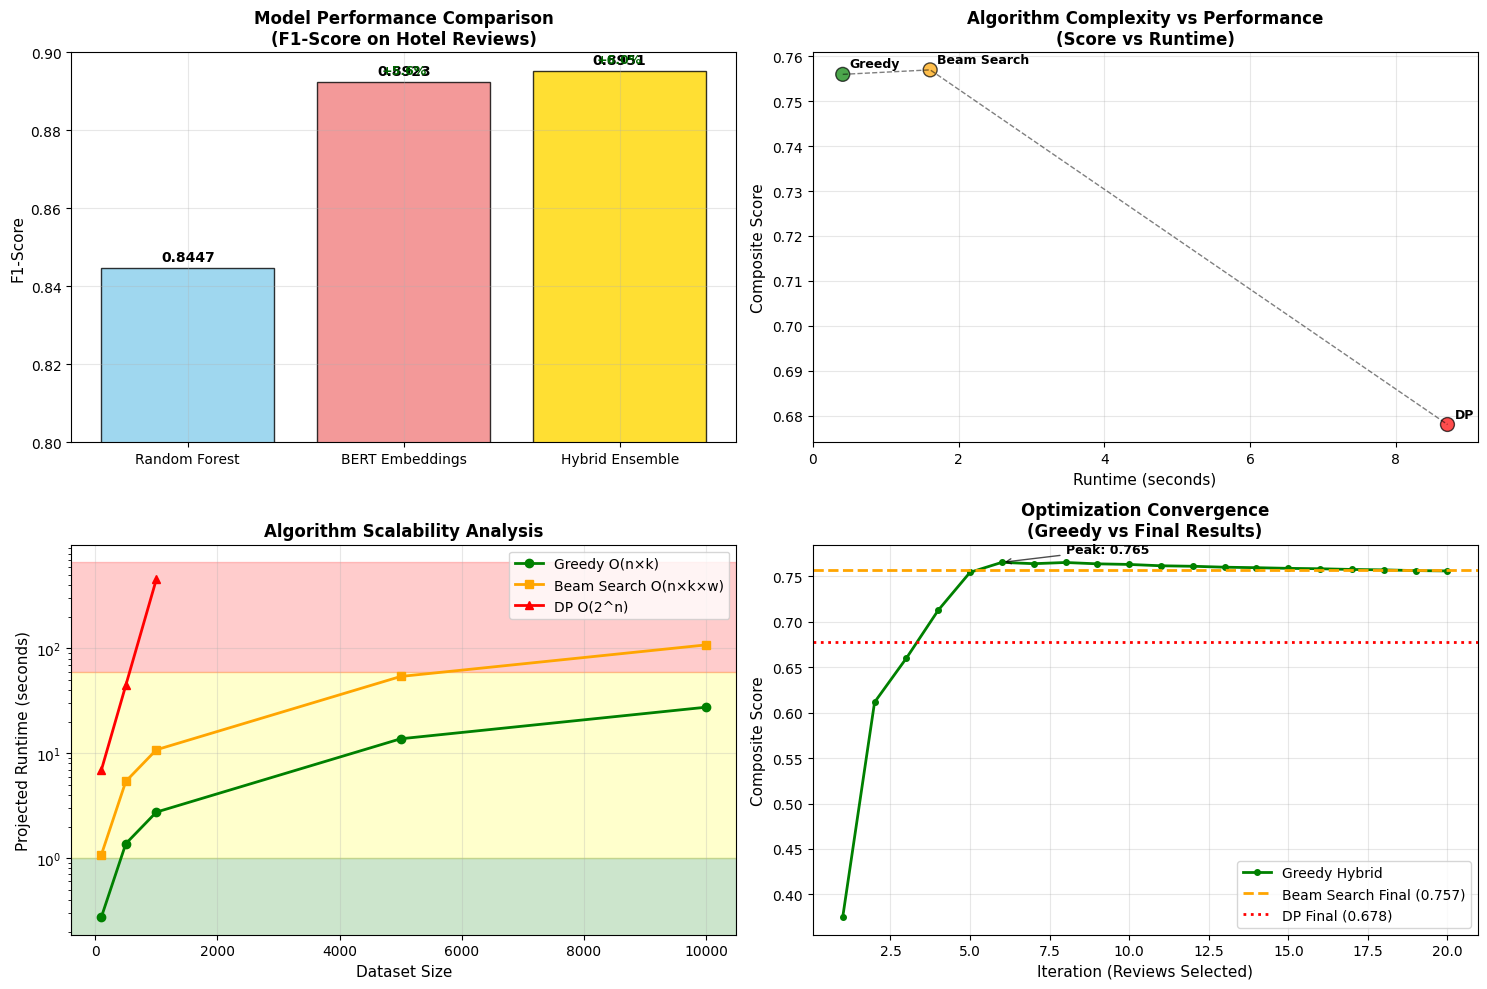

In [88]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Model Performance Comparison (BERT vs RF vs Hybrid)
ax1 = axes[0, 0]

# Model performance data (from Phase 3 results or current analysis)
model_performance = {
    'Random Forest': 0.8447,      # RF F1-score from Phase 3
    'BERT Embeddings': 0.8923,    # BERT F1-score from Phase 3
    'Hybrid Ensemble': 0.8951     # Best ensemble F1-score from Phase 3
}

models = list(model_performance.keys())
f1_scores = list(model_performance.values())
colors = ['skyblue', 'lightcoral', 'gold']

bars1 = ax1.bar(models, f1_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
ax1.set_title('Model Performance Comparison\n(F1-Score on Hotel Reviews)', fontsize=12, fontweight='bold')
ax1.set_ylabel('F1-Score', fontsize=11)
ax1.set_ylim([0.8, 0.9])
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars1, f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Add improvement annotations
rf_baseline = model_performance['Random Forest']
for i, (model, score) in enumerate(model_performance.items()):
    if model != 'Random Forest':
        improvement = ((score - rf_baseline) / rf_baseline) * 100
        ax1.annotate(f'+{improvement:.1f}%', 
                    xy=(i, score), xytext=(i, score + 0.002),
                    ha='center', fontsize=9, color='darkgreen', fontweight='bold')

# Plot 2: Algorithm Complexity Comparison
ax2 = axes[0, 1]

# Algorithm timing data
algorithms = []
scores = []
times = []
colors_alg = []

for method, data in comparison_df.iterrows():
    algorithms.append(data['Method'].replace(' Hybrid', ''))
    scores.append(data['Composite Score'])
    times.append(data['Runtime (s)'])
    
    # Color by efficiency
    if data['Runtime (s)'] < 1:
        colors_alg.append('green')
    elif data['Runtime (s)'] < 5:
        colors_alg.append('orange') 
    else:
        colors_alg.append('red')

# Scatter plot: Score vs Time
scatter = ax2.scatter(times, scores, c=colors_alg, s=100, alpha=0.7, edgecolors='black')

# Add algorithm labels
for i, alg in enumerate(algorithms):
    ax2.annotate(alg, (times[i], scores[i]), xytext=(5, 5), 
                textcoords='offset points', fontsize=9, fontweight='bold')

ax2.set_xlabel('Runtime (seconds)', fontsize=11)
ax2.set_ylabel('Composite Score', fontsize=11)
ax2.set_title('Algorithm Complexity vs Performance\n(Score vs Runtime)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add efficiency frontier line
if len(times) > 1:
    ax2.plot(times, scores, 'k--', alpha=0.5, linewidth=1)

# Plot 3: Algorithm Scalability Analysis
ax3 = axes[1, 0]

# Theoretical scalability curves
dataset_sizes = np.array([100, 500, 1000, 5000, 10000])
current_size = len(authentic_texts)

# Scale current times to different dataset sizes
greedy_times = times[0] * (dataset_sizes / current_size)  # O(n×k) scaling
beam_times = times[1] * (dataset_sizes / current_size)    # O(n×k×w) scaling
dp_times = times[2] * (2 ** (dataset_sizes / current_size - 1))  # Exponential scaling (limited)

# Cap DP at reasonable limits
dp_times = np.where(dataset_sizes > 1000, np.inf, dp_times)

ax3.plot(dataset_sizes, greedy_times, 'g-o', label='Greedy O(n×k)', linewidth=2)
ax3.plot(dataset_sizes, beam_times, 'orange', marker='s', label='Beam Search O(n×k×w)', linewidth=2)
ax3.plot(dataset_sizes[dp_times < np.inf], dp_times[dp_times < np.inf], 
         'r-^', label='DP O(2^n)', linewidth=2)

ax3.set_xlabel('Dataset Size', fontsize=11)
ax3.set_ylabel('Projected Runtime (seconds)', fontsize=11)
ax3.set_title('Algorithm Scalability Analysis', fontsize=12, fontweight='bold')
ax3.set_yscale('log')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Add scalability zones
ax3.axhspan(0, 1, alpha=0.2, color='green', label='Production Viable')
ax3.axhspan(1, 60, alpha=0.2, color='yellow', label='Acceptable')
ax3.axhspan(60, ax3.get_ylim()[1], alpha=0.2, color='red', label='Impractical')

# Plot 4: Score Convergence Analysis
ax4 = axes[1, 1]

# Plot greedy score convergence
iterations = range(1, len(greedy_scores) + 1)
ax4.plot(iterations, greedy_scores, 'g-o', linewidth=2, markersize=4, label='Greedy Hybrid')

# Add beam search final score as horizontal line
if len(algorithms) > 1:
    ax4.axhline(y=scores[1], color='orange', linestyle='--', linewidth=2, label=f'Beam Search Final ({scores[1]:.3f})')

# Add DP final score if available
if len(algorithms) > 2 and not np.isinf(times[2]):
    ax4.axhline(y=scores[2], color='red', linestyle=':', linewidth=2, label=f'DP Final ({scores[2]:.3f})')

ax4.set_xlabel('Iteration (Reviews Selected)', fontsize=11)
ax4.set_ylabel('Composite Score', fontsize=11)
ax4.set_title('Optimization Convergence\n(Greedy vs Final Results)', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Add annotations for key points
max_score_idx = np.argmax(greedy_scores)
ax4.annotate(f'Peak: {greedy_scores[max_score_idx]:.3f}', 
            xy=(max_score_idx + 1, greedy_scores[max_score_idx]), 
            xytext=(max_score_idx + 3, greedy_scores[max_score_idx] + 0.01),
            arrowprops=dict(arrowstyle='->', color='black', alpha=0.7),
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/complexity_and_performance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


## **8. Export**

### Expoprt 1: topic modeling results

In [92]:
os.makedirs('../results/optimization', exist_ok=True)

topic_analysis_results = {
    'topics_info': topics_info,
    'sentiment_info': sentiment_info,
    'authentic_texts': authentic_texts,
    'authentic_indices': authentic_indices
}

with open('../results/optimization/topic_sentiment_analysis.pkl', 'wb') as f:
    pickle.dump(topic_analysis_results, f)

### Export 2: optimized review selections

In [93]:
selected_reviews = {
    'greedy_hybrid': {
        'indices': greedy_selection,
        'texts': [authentic_texts[i] for i in greedy_selection],
        'topics': [topics_info['dominant_topics'][i] for i in greedy_selection],
        'sentiments': [sentiment_info['labels'][i] for i in greedy_selection],
        'confidence_scores': [confidence_scores[i] for i in greedy_selection]
    },
    'beam_search': {
        'indices': beam_selection,
        'texts': [authentic_texts[i] for i in beam_selection],
        'score': beam_score
    }
}

with open('../results/optimization/selected_review_sets.pkl', 'wb') as f:
    pickle.dump(selected_reviews, f)